In [20]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "Finalterm" / "student-mat.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

| No. | Variable    | 說明 |
|-----|-------------|------|
| 1   | school      | 就讀學校（GP：Gabriel Pereira；MS：Mousinho da Silveira） |
| 2   | sex         | 性別（F：female；M：male） |
| 3   | age         | 年齡（15–22） |
| 4   | address     | 住家型態（U：urban；R：rural） |
| 5   | famsize     | 家庭人數（LE3：≤3；GT3：>3） |
| 6   | Pstatus     | 父母同住狀態（T：together；A：apart） |
| 7   | Medu        | 母親教育程度（0：none；1：primary；2：5–9th；3：secondary；4：higher） |
| 8   | Fedu        | 父親教育程度（0：none；1：primary；2：5–9th；3：secondary；4：higher） |
| 9   | Mjob        | 母親職業（teacher／health／services／at_home／other） |
| 10  | Fjob        | 父親職業（teacher／health／services／at_home／other） |
| 11  | reason      | 選校原因（home／reputation／course／other） |
| 12  | guardian    | 監護人（mother／father／other） |
| 13  | traveltime  | 通學時間（1：<15min；2：15–30；3：30–60；4：>1hr） |
| 14  | studytime   | 每週讀書時間（1：<2hr；2：2–5；3：5–10；4：>10） |
| 15  | failures    | 過去被當次數（1–3；≥3 記為 4） |
| 16  | schoolsup   | 額外教育輔導（yes／no） |
| 17  | famsup      | 家庭教育支持（yes／no） |
| 18  | paid        | 額外付費課程（yes／no） |
| 19  | activities  | 課外活動（yes／no） |
| 20  | nursery     | 是否上過幼兒園（yes／no） |
| 21  | higher      | 是否想讀高等教育（yes／no） |
| 22  | internet    | 家中是否有網路（yes／no） |
| 23  | romantic    | 是否有戀愛關係（yes／no） |
| 24  | famrel      | 家庭關係品質（1–5） |
| 25  | freetime    | 放學後自由時間（1–5） |
| 26  | goout       | 與朋友外出頻率（1–5） |
| 27  | Dalc        | 工作日酒精攝取（1–5） |
| 28  | Walc        | 週末酒精攝取（1–5） |
| 29  | health      | 健康狀況（1–5） |
| 30  | absences    | 缺課次數（0–93） |
| 31  | G1          | 第一階段成績（0–20） |
| 32  | G2          | 第二階段成績（0–20） |
| 33  | G3          | 最終成績（0–20，預測目標） |


In [21]:
data = pd.read_csv(data_path).rename(columns={'G3':'FinalGrade'})
data = data[data['age'].isin([15, 16, 17, 18])]
print(data['age'].value_counts())
data.loc[data['absences'] >= 4, 'absences'] = 4
print(data['absences'].value_counts())
print(data.shape)

age
16    104
17     98
18     82
15     82
Name: count, dtype: int64
absences
4    185
0    108
2     64
3      6
1      3
Name: count, dtype: int64
(366, 33)


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 0 to 393
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      366 non-null    object
 1   sex         366 non-null    object
 2   age         366 non-null    int64 
 3   address     366 non-null    object
 4   famsize     366 non-null    object
 5   Pstatus     366 non-null    object
 6   Medu        366 non-null    int64 
 7   Fedu        366 non-null    int64 
 8   Mjob        366 non-null    object
 9   Fjob        366 non-null    object
 10  reason      366 non-null    object
 11  guardian    366 non-null    object
 12  traveltime  366 non-null    int64 
 13  studytime   366 non-null    int64 
 14  failures    366 non-null    int64 
 15  schoolsup   366 non-null    object
 16  famsup      366 non-null    object
 17  paid        366 non-null    object
 18  activities  366 non-null    object
 19  nursery     366 non-null    object
 20  higher      366

In [8]:
# ANOVA 模型
model = smf.ols("FinalGrade ~ C(studytime)", data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                   sum_sq     df         F    PR(>F)
C(studytime)    92.375151    3.0  1.492515  0.216229
Residual      7468.335232  362.0       NaN       NaN


In [9]:
# 資源變項
vars_resouce = ["paid", "schoolsup", "famsup", "internet", "address", "activities"]

# 行為變項
vars_behavior = ['freetime', "goout", "absences", "failures"]

# 分類變項（類別型使用 C()）
cat_vars = vars_resouce

# 數值變項
num_vars = vars_behavior

vars = cat_vars + num_vars

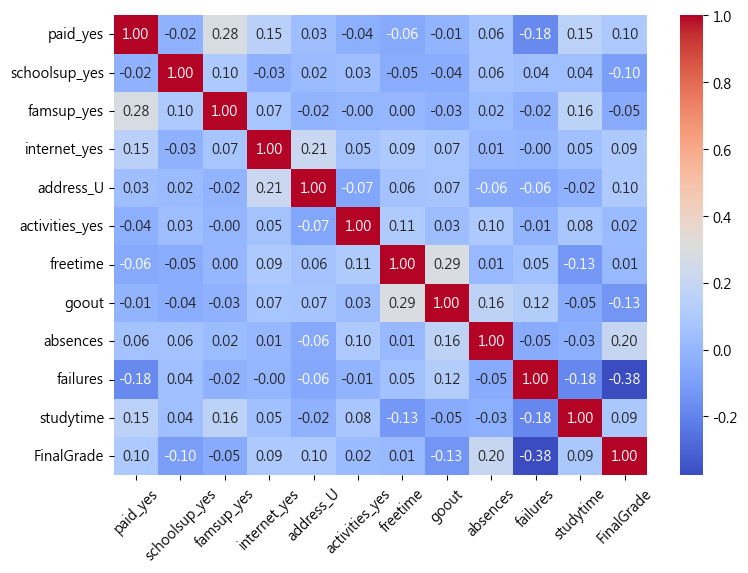

In [10]:
# 1. 將類別變項轉為 dummy（去掉第一個避免共線）
cat_dummies = pd.get_dummies(data[cat_vars], drop_first=True)

# 2. 數值變項照原本使用
num_data = data[num_vars + ["studytime", 'FinalGrade']]

# 3. 合併成一個可做 corr 的資料表
corr_data = pd.concat([cat_dummies, num_data], axis=1)

# 4. 繪製 heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='address', ylabel='FinalGrade'>

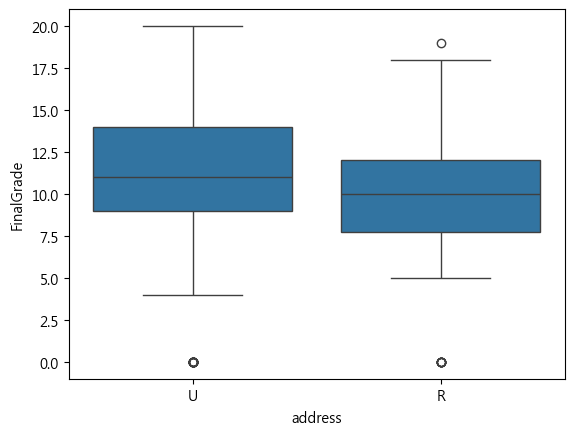

In [19]:
sns.boxplot(x='address', y="FinalGrade", data=data)

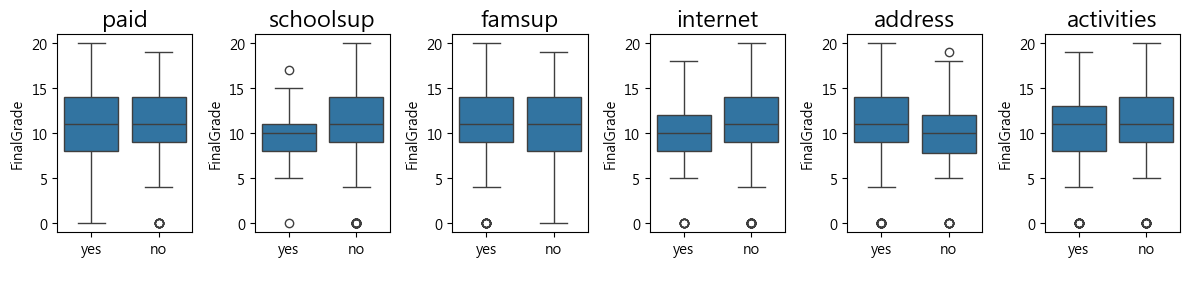

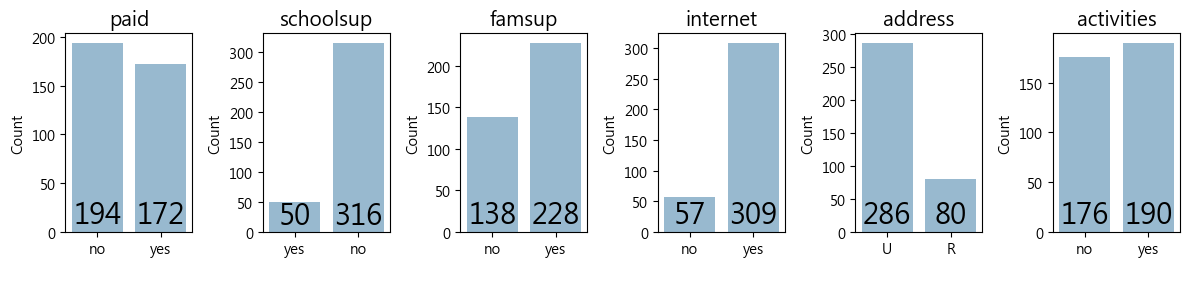

In [25]:
plt.figure(figsize=(12, 3))

for i, var in enumerate(vars_resouce, 1):
    plt.subplot(1, 6, i)
    sns.boxplot(x=var, y="FinalGrade", data=data)
    plt.title(var, fontsize=16)
    plt.xticks(ticks=[0, 1], labels=['yes', 'no'])
    plt.xlabel(" ")
    plt.ylabel("FinalGrade")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))

for i, var in enumerate(vars_resouce, 1):
    plt.subplot(1, 6, i)
    ax = sns.countplot(x=var, data=data, alpha=0.5)
    plt.title(var, fontsize=14)
    plt.xlabel(" ")
    plt.ylabel("Count")
    # 加上每個 bar 的數字
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,   # x 位置
            2,                          # y 位置
            f"{int(height)}",                # 顯示的文字
            ha="center", va="bottom", fontsize=20
        )
plt.tight_layout()
plt.show()

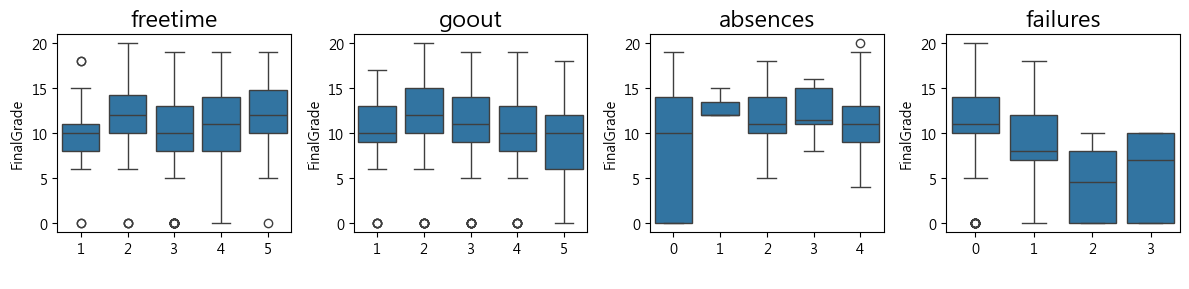

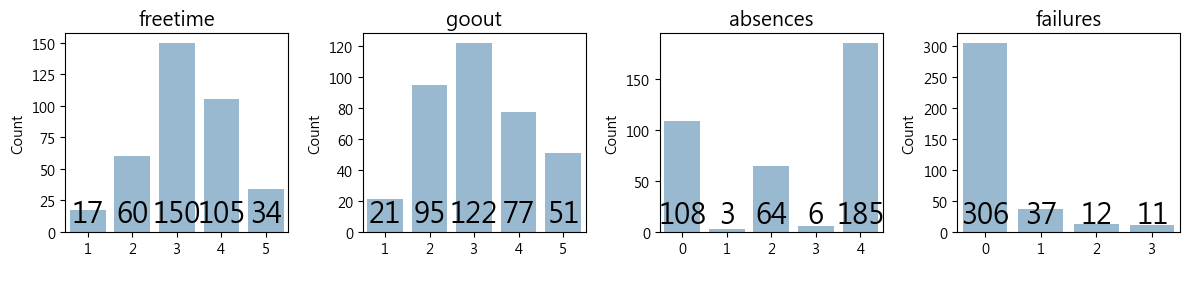

In [12]:
plt.figure(figsize=(12, 3))

for i, var in enumerate(vars_behavior, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(x=var, y="FinalGrade", data=data)
    plt.title(var, fontsize=16)
    plt.xlabel(" ")
    plt.ylabel("FinalGrade")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))

for i, var in enumerate(vars_behavior, 1):
    plt.subplot(1, 4, i)
    ax = sns.countplot(x=var, data=data, alpha=0.5)
    plt.title(var, fontsize=14)
    plt.xlabel(" ")
    plt.ylabel("Count")
    # 加上每個 bar 的數字
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,   # x 位置
            2,                          # y 位置
            f"{int(height)}",                # 顯示的文字
            ha="center", va="bottom", fontsize=20
        )
plt.tight_layout()
plt.show()

In [13]:
num_vars = num_vars + ['studytime']
# 建立 formula
terms = []
for v in cat_vars:
    terms.append(f"C({v})")
for v in num_vars:
    terms.append(v)

formula_model2 = "FinalGrade ~ " + " + ".join(terms)

print("Model 2 formula：")
print(formula_model2)

# 擬合模型
model2 = smf.ols(formula_model2, data=data).fit()
print(model2.summary())

Model 2 formula：
FinalGrade ~ C(paid) + C(schoolsup) + C(famsup) + C(internet) + C(address) + C(activities) + freetime + goout + absences + failures + studytime
                            OLS Regression Results                            
Dep. Variable:             FinalGrade   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     9.291
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           1.11e-14
Time:                        21:18:46   Log-Likelihood:                -1027.1
No. Observations:                 366   AIC:                             2078.
Df Residuals:                     354   BIC:                             2125.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err       

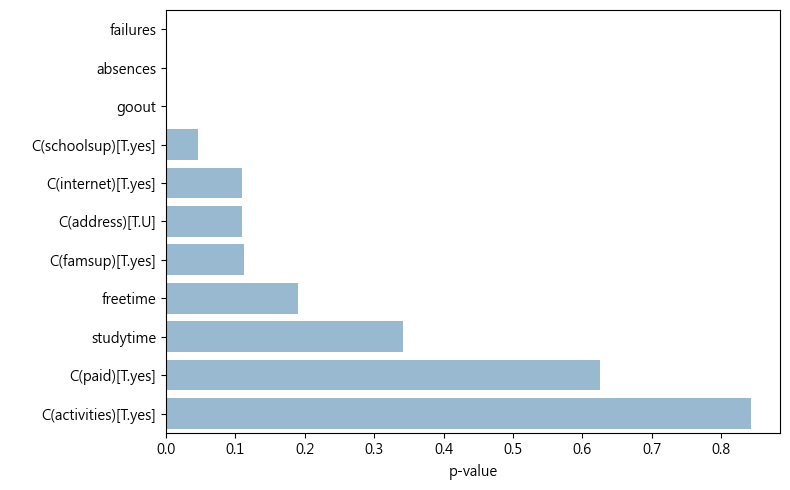

In [14]:
# 取出 p-value（排除 Intercept）
pvals = model2.pvalues.drop("Intercept")

# 依 p-value 由小到大排序
pvals_sorted = pvals.sort_values(ascending=True)

# 圖形
plt.figure(figsize=(8, 5))
sns.barplot(
    x=pvals_sorted,
    y=pvals_sorted.index,
    orient='h', alpha=0.5
)

plt.xlabel("p-value")
plt.ylabel("  ")
plt.tight_layout()
plt.show()

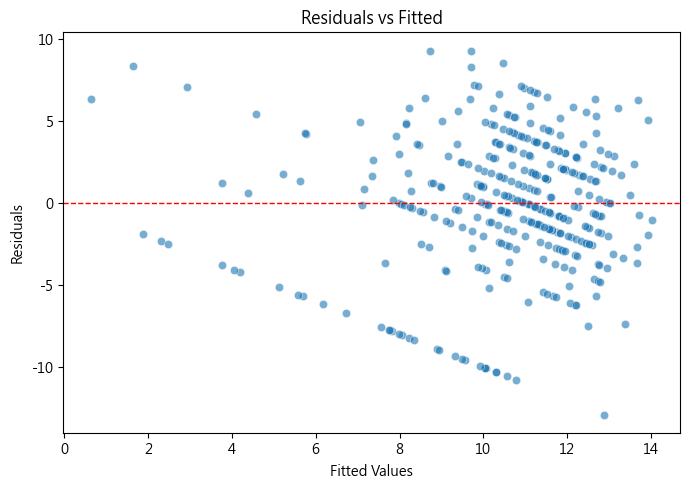

<Figure size 600x600 with 0 Axes>

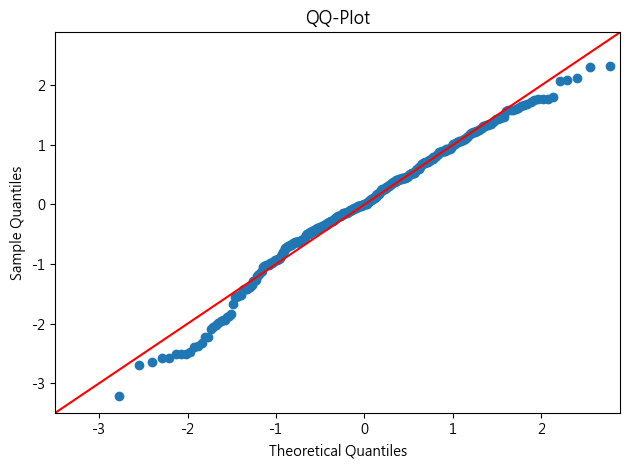

In [15]:
# 取得殘差與預測值
residuals = model2.resid
fitted = model2.fittedvalues

# -----------------------------
# 1. Residuals vs Fitted Scatter
# -----------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

# -----------------------------
# 2. QQ Plot（檢查殘差常態性）
# -----------------------------
plt.figure(figsize=(6,6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ-Plot")
plt.tight_layout()
plt.show()

In [16]:
num_cols = data.select_dtypes(include=['int64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

<Axes: >

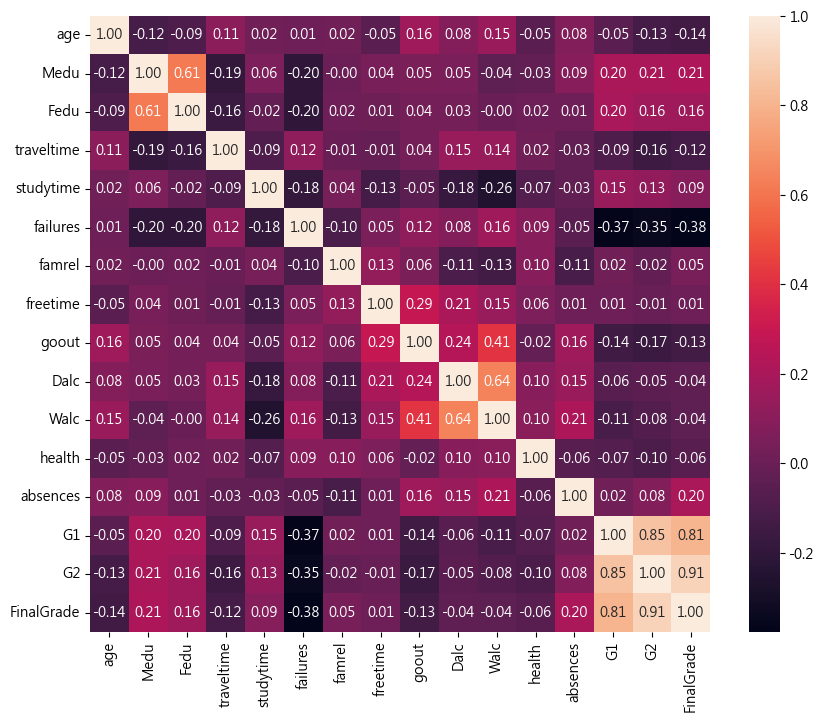

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(data=data[num_cols].corr(), fmt='.2f', annot=True)

<Axes: xlabel='PC1', ylabel='PC2'>

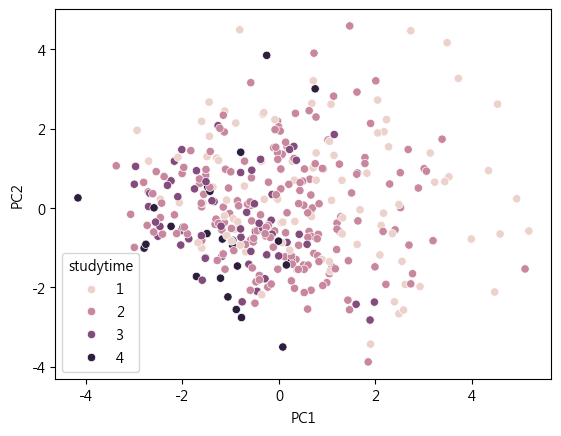

In [18]:
scaler = StandardScaler()
num_cols = data.select_dtypes(include=['float64', 'int64']).columns

X = data[num_cols].drop(columns=['FinalGrade'])
X_std = scaler.fit_transform(X)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(data=X_pca, index=X.index, columns=[f'PC{i}' for i in range(1, X_pca.shape[1]+1)])
sns.scatterplot(x=X_pca_df['PC1'], y=X_pca_df['PC2'], hue=data['studytime'])